In [7]:
# import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek


In [8]:
from utils import *

In [9]:
# Download data
df = pd.read_csv('../data/workable_data.csv')

In [10]:
print(df.shape)
df.head()

(1516948, 20)


,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,Pressure_switch,Oil_level,Caudal_impulses,day,month,hour,minute,second,failure
0,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1,2,0,0,0,0
1,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1,2,0,0,10,0
2,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1,2,0,0,19,0
3,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1,2,0,0,29,0
4,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1,2,0,0,39,0


In [11]:
# Select target and features
X = df.drop('failure', axis=1)
y = df['failure']


# Chronological Split + threshold prediction

In [12]:
# Split the data in a way that the test data contains 1 of the failures and the train 3 of the failures
split_index = int(len(df) * 0.7)
X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

In [13]:
# make sure test data contain failure values
print(y_test.unique())
X_test.head()

[0 1]


,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,Pressure_switch,Oil_level,Caudal_impulses,day,month,hour,minute,second
1061863,-0.01,8.462,8.450,-0.018,8.466,64.800,0.0375,1.0,0.0,1.0,1.0,1.0,1.0,1.0,29,6,16,18,17
1061864,-0.01,8.448,8.436,-0.016,8.452,64.825,0.0400,1.0,0.0,1.0,1.0,1.0,1.0,1.0,29,6,16,18,27
1061865,-0.01,8.436,8.426,-0.016,8.438,64.625,0.0400,1.0,0.0,1.0,1.0,1.0,1.0,1.0,29,6,16,18,37
1061866,-0.01,8.424,8.414,-0.016,8.426,64.550,0.0400,1.0,0.0,1.0,1.0,1.0,1.0,1.0,29,6,16,18,47
1061867,-0.01,8.412,8.402,-0.016,8.412,64.475,0.0400,1.0,0.0,1.0,1.0,1.0,1.0,1.0,29,6,16,18,57


In [14]:
#Fit the model
rf = RandomForestClassifier(
    max_depth=10,         
    min_samples_leaf=10,   
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [15]:
# Lower threshold to 0.15 to increase recall — catch more failures at the cost of precision
y_prob = rf.predict_proba(X_test)[:, 1]
# Default threshold is 0.5 — too strict for rare failures. 
# Prioritizes Recall (catching real failures) over Precision (avoiding false alarms)
# At 0.15, we flag failure if model is ≥15% confident
y_pred = (y_prob >= 0.15).astype(int) 
print("Rando Forest Report:\n", classification_report(y_test, y_pred, zero_division=0))

Rando Forest Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    453463
           1       0.52      0.50      0.51      1622

    accuracy                           1.00    455085
   macro avg       0.76      0.75      0.75    455085
weighted avg       1.00      1.00      1.00    455085



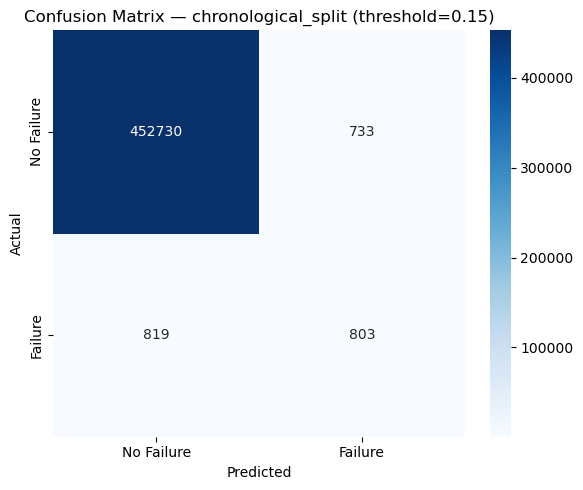

In [16]:
results = evaluate_model(
    rf, 
    X_train, 
    X_test, 
    y_train, 
    y_test, 
    'chronological_split', 
    'chronological split, '
    'threshold 0.15', 
    0.15
)

In [17]:
results

,experiment_name,explanation,model,threshold,F1_Train(Class1),F1_Test(Class1),Precision_Test(Class1),Recall_Test(Class1),Overfit_Gap(F1),ROC_AUC
0,chronological_split,"chronological split, threshold 0.15",RandomForestClassifier,0.15,0.9976,0.5085,0.5228,0.4951,0.489,0.9973


### Conclutions   
- For splitting the data we need also failures on the train data. That is why we splited it in a chronological way.
- We need to use threshold lower than 0,5 when predicting, at the cost of more false alarms
- The recall on the class 1 is the most important metric in this case (0,5), because indicates how many real failures we catchet out of all real failures

# Udersample 50/50 failure on train data

In [18]:
# 1.0 = 50/50 balance between normal and failure rows
rus = RandomUnderSampler(sampling_strategy=1.0, random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

print(f"BEFORE undersampling → Normal: {sum(y_train == 0):,} | Failures: {sum(y_train == 1):,}")
print(f"AFTER  undersampling → Normal: {sum(y_train_res == 0):,} | Failures: {sum(y_train_res == 1):,}")

BEFORE undersampling → Normal: 1,033,531 | Failures: 28,332
AFTER  undersampling → Normal: 28,332 | Failures: 28,332


In [19]:
# Fit the model
rf_res = RandomForestClassifier(
    max_depth=10,         
    min_samples_leaf=10,   
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_res.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [20]:
y_prob = rf_res.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.15).astype(int)

print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    453463
           1       0.27      0.74      0.40      1622

    accuracy                           0.99    455085
   macro avg       0.64      0.86      0.70    455085
weighted avg       1.00      0.99      0.99    455085



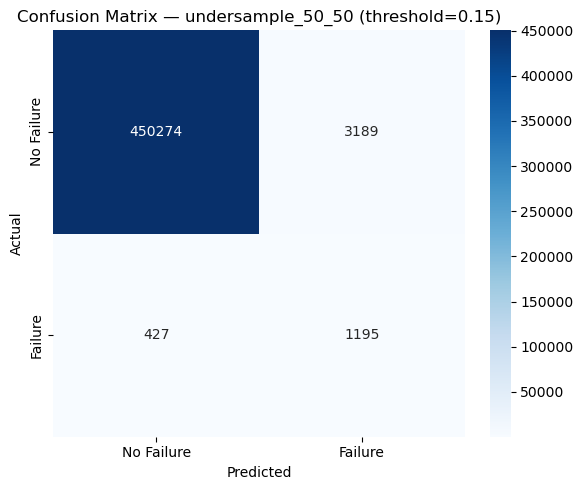

In [21]:
results = evaluate_model(
    rf_res,
    X_train_res, 
    X_test,    
    y_train_res, 
    y_test,
    'undersample_50_50',
    'chronological split + 50/50 undersampling + threshold 0.15',
    threshold=0.15
)

In [22]:
results

,experiment_name,explanation,model,threshold,F1_Train(Class1),F1_Test(Class1),Precision_Test(Class1),Recall_Test(Class1),Overfit_Gap(F1),ROC_AUC
0,undersample_50_50,chronological split + 50/50 undersampling + th...,RandomForestClassifier,0.15,0.9997,0.3979,0.2726,0.7367,0.6018,0.9934


### Conclutions  
- The model improved Recall score significatly
- At the cost of a big increase of false alarms and a bit more of overfitting


# Udersample 70/30 failure on train data
$sampling\_strategy = \frac{minority}{majority}=\frac{30}{70}\approx 0.4286$

In [23]:
# Undersampling
rus = RandomUnderSampler(sampling_strategy=0.4286, random_state=42)
X_train_res70, y_train_res70 = rus.fit_resample(X_train, y_train)

In [24]:
# Fit the model
rf_res70 = RandomForestClassifier(
    max_depth=10,         
    min_samples_leaf=10,   
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_res70.fit(X_train_res70, y_train_res70)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [25]:
y_prob = rf_res70.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.15).astype(int)

print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    453463
           1       0.30      0.74      0.43      1622

    accuracy                           0.99    455085
   macro avg       0.65      0.86      0.71    455085
weighted avg       1.00      0.99      0.99    455085



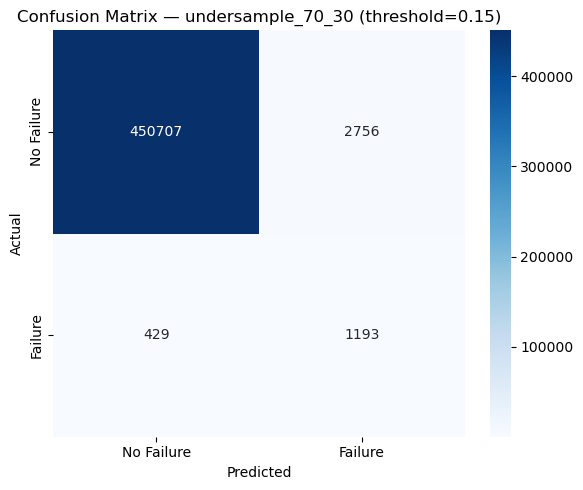

In [26]:
results = evaluate_model(
    rf_res70,
    X_train_res70, 
    X_test,    
    y_train_res70, 
    y_test,
    'undersample_70_30',
    'chronological split + 70/30 undersampling + threshold 0.15',
    threshold=0.15
)

In [27]:
results

,experiment_name,explanation,model,threshold,F1_Train(Class1),F1_Test(Class1),Precision_Test(Class1),Recall_Test(Class1),Overfit_Gap(F1),ROC_AUC
0,undersample_70_30,chronological split + 70/30 undersampling + th...,RandomForestClassifier,0.15,0.9996,0.4283,0.3021,0.7355,0.5714,0.996


## Conclusions
- Recall droped a bit but the Precision and F1 scores improved
- Less false alarms, 2 more false positives
- Less overfiting
- In general this split improves the model

# Oversampling with SMOTE

In [ ]:
# SMOTE creates synthetic failure rows by interpolating between real ones

# strategy = failures / normals
# 0.05  →  1 failure per 20 normals  (barely changes anything)
# 0.1   →  1 failure per 10 normals
# 0.5   →  1 failure per 2 normals   
# 1.0   →  1 failure per 1 normal    (perfect 50/50)

for strategy in [0.05, 0.1, 0.5, 1.0]:
    smote = SMOTE(sampling_strategy=strategy, random_state=42)
    X_res, y_res = smote.fit_resample(X_train, y_train)
    
    rf_temp = RandomForestClassifier(
    max_depth=10,         
    min_samples_leaf=10,   
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
    rf_temp.fit(X_res, y_res)
    
    y_prob = rf_temp.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.15).astype(int)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    
    print(f"strategy={strategy} → Precision: {report['1']['precision']:.3f} | Recall: {report['1']['recall']:.3f} | F1: {report['1']['f1-score']:.3f}")


| Strategy | Precision | Recall | F1 |
--- | --- | --- | ---
|  0.05 | Precision: 0.586 | Recall: 0.691 | F1: 0.634 | 
| 0.1 | Precision: 0.592 | Recall: 0.616 | F1: 0.604  |
|  0.5 | Precision: 0.626 | Recall: 0.567 | F1: 0.595  |
|  1.0 | Precision: 0.600 | Recall: 0.520 | F1: 0.557  |

In [28]:
# I chose sampling_strategy = 0.05 because is the biggest Recall
smote = SMOTE(sampling_strategy=0.05, random_state=42) 
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [29]:
# Fit the model
rf_sm = RandomForestClassifier(
    max_depth=10,         
    min_samples_leaf=10,   
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_sm.fit(X_train_sm, y_train_sm)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

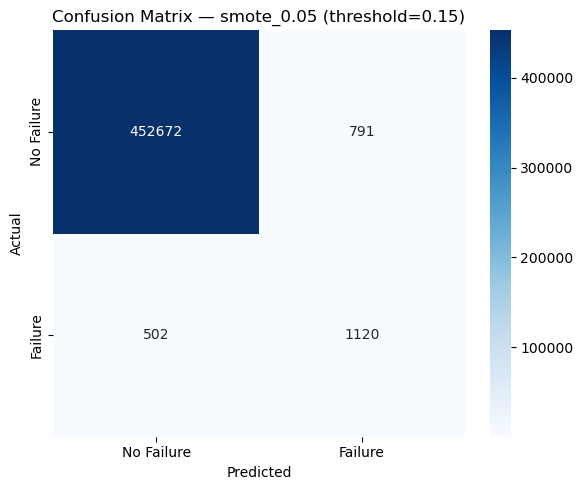

In [30]:
results = evaluate_model(
    rf_sm,
    X_train_sm, X_test,
    y_train_sm, y_test,
    'smote_0.05',
    'chronological split + SMOTE sampling_strategy=0.0.5 + threshold 0.15',
    threshold=0.15
)

In [31]:
results

,experiment_name,explanation,model,threshold,F1_Train(Class1),F1_Test(Class1),Precision_Test(Class1),Recall_Test(Class1),Overfit_Gap(F1),ROC_AUC
0,smote_0.05,chronological split + SMOTE sampling_strategy=...,RandomForestClassifier,0.15,0.9987,0.634,0.5861,0.6905,0.3646,0.9959


## Conclutions  
- Recall dropped but it is still good
- F1 Precision and overfit gap improved draastically

# SMOTETomek  
SMOTE → oversamples the minority class by creating synthetic samples  
Tomek Links → cleans the border between classes by removing overlapping/ambiguous samples from the majority class

In [6]:
# SMOTE creates synthetic failure rows by interpolating between real ones

# strategy = failures / normals
# 0.05  →  1 failure per 20 normals  
# 0.1   →  1 failure per 10 normals
# 0.5   →  1 failure per 2 normals   
# 1.0   →  1 failure per 1 normal  

for strategy in [0.05, 0.1, 0.5, 1.0]:
    smote = SMOTETomek(sampling_strategy=strategy, random_state=42, n_jobs=-1)
    X_s, y_s = smote.fit_resample(X_train, y_train)
    
    rf_temp = RandomForestClassifier(
    max_depth=10,         
    min_samples_leaf=10,   
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
    rf_temp.fit(X_s, y_s)
    
    y_prob = rf_temp.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.15).astype(int)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    
    print(f"strategy={strategy} | Precision: {report['1']['precision']:.3f} | Recall: {report['1']['recall']:.3f} | F1: {report['1']['f1-score']:.3f}")


strategy=0.05 | Precision: 0.541 | Recall: 0.445 | F1: 0.488
strategy=0.1 | Precision: 0.593 | Recall: 0.624 | F1: 0.608
strategy=0.5 | Precision: 0.628 | Recall: 0.573 | F1: 0.600
strategy=1.0 | Precision: 0.600 | Recall: 0.520 | F1: 0.557


STRATEGY | PRECISION | RECALL | F1
--- | --- | --- | ---
strategy=0.05 | Precision: 0.541 | Recall: 0.445 | F1: 0.488
strategy=0.1 | Precision: 0.593 | Recall: 0.624 | F1: 0.608
strategy=0.5 | Precision: 0.628 | Recall: 0.573 | F1: 0.600
strategy=1.0 | Precision: 0.600 | Recall: 0.520 | F1: 0.557

In [32]:
# Best strategy 0.1
smt = SMOTETomek(sampling_strategy=0.1, random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train, y_train)
print(pd.Series(y_train_smt).value_counts())

failure
0    1033531
1     103353
Name: count, dtype: int64


In [33]:
rf_smt = RandomForestClassifier(
    max_depth=10,         
    min_samples_leaf=10,   
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_smt.fit(X_train_smt, y_train_smt)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

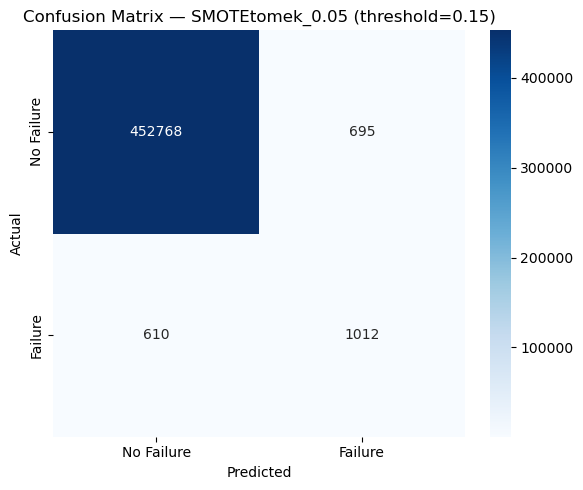

In [34]:
results = evaluate_model(
    rf_smt,
    X_train_smt, X_test,
    y_train_smt, y_test,
    'SMOTEtomek_0.05',
    'chronological split + SMOTEtomek sampling_strategy=0.0.5 + threshold=0.15',
    threshold=0.15
)

## Conclution 
It is worse overall